# Prototype Code für Ortstabelle

## 1. Dependencies importieren

In [1]:
import pandas as pd
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt

Flag für Export bei Run All (grosse Dateien)

In [2]:
DO_EXPORT = False #Auf True setzen, um erneute Datei-Exporte zu vermeiden

## 2. Daten importieren

In [3]:
# aktuelles Notebook-Verzeichnis
BASE_DIR = Path().resolve()
# zum Projekt-Root hochgehen
PROJECT_ROOT = BASE_DIR.parent

# Pfade definieren
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EXPORT_DIR = PROJECT_ROOT / "exports"
places_path = PROCESSED_DIR / "places.csv"

### 2.1 Import Orte

In [4]:
places = pd.read_csv(places_path, sep=";")
places.columns = places.columns.str.strip()
places

,place_id,place_name,zone_expected,zone_label,canton,language_region,lat,lon,x_lv95,y_lv95,place_type,is_featured,short_description,elevation_m,marker_priority,zoom_level,display_order,image_name
0,aarau,Aarau,1,Mittelland,AG,de,47.392466,8.043742,2645686.0,1249247.0,Ort,True,Aarau liegt im Mittelland und gehört zu den Re...,384.90860,2,9,10,NaN
1,adelboden,Adelboden,2,Voralpen,BE,de,46.492460,7.558743,2609221.0,1149023.0,Ort,False,NaN,1350.00430,2,9,25,NaN
2,adliswil,Adliswil,1,Mittelland,ZH,de,47.311713,8.524800,2682128.0,1240661.0,Ort,False,NaN,449.77658,2,9,11,NaN
3,aesch_bl,Aesch BL,1,Mittelland,BL,de,47.468185,7.597392,2611970.0,1257502.0,Ort,False,NaN,312.86070,2,9,12,NaN
4,affoltern_am_albis,Affoltern am Albis,1,Mittelland,ZH,de,47.278410,8.452032,2676674.0,1236885.0,Ort,False,NaN,490.02396,2,9,13,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,st_moritz,St. Moritz,3,Alpen,GR,de,46.497616,9.838751,2784225.0,1152407.0,Ort,True,Die Region St. Moritz erlebt vergleichsweise w...,1826.94700,2,9,45,NaN
61,winterthur,Winterthur,1,Mittelland,ZH,de,47.498744,8.727662,2697124.0,1261685.0,Ort,False,NaN,440.63670,2,9,5,NaN
62,zermatt,Zermatt,3,Alpen,VS,de,46.022109,7.747366,2623908.0,1096776.0,Ort,True,Der Tourismus in Zermatt ist eng mit Schnee un...,1609.21750,2,9,46,NaN
63,zuoz,Zuoz,3,Alpen,GR,rm,46.602081,9.959290,2793101.0,1164304.0,Ort,False,NaN,1717.01660,2,9,52,NaN


### 2.2 Import historische Klima-Daten

In [5]:
tg_ch = xr.open_dataarray(EXPORT_DIR / "tg_ch.nc")
zone_tg = xr.open_dataarray(EXPORT_DIR / "zone_tg.nc")

In [6]:
tx_ch = xr.open_dataarray(EXPORT_DIR / "tx_ch.nc")
zone_tx = xr.open_dataarray(EXPORT_DIR / "zone_tx.nc")

### 2.3 Import Zukunftsszenarien

In [7]:
ds_tas_all = xr.open_dataset(
    EXPORT_DIR / "ds_tas_all.nc",
    engine="netcdf4",
    chunks={"time": 365}
)
#Speicherschonend mit Chunks
ds_tasmax_all = xr.open_dataset(
    EXPORT_DIR / "ds_tasmax_all.nc",
    engine="netcdf4",
    chunks={"time": 365}
)


zone_ch2025 = xr.open_dataarray(EXPORT_DIR / "zone_ch2025.nc")

#ds_tas_all ist ein dataset und die gesuchten Variablen müssen noch zugewiesen werden
tas_ch2025 = ds_tas_all["tas"]
tasmax_ch2025 = ds_tasmax_all["tasmax"]

In [8]:
print(ds_tas_all)
print(tas_ch2025)
print(tasmax_ch2025)
print(zone_ch2025)

<xarray.Dataset> Size: 19GB
Dimensions:                 (scenario: 5, time: 10950, y: 240, x: 370)
Coordinates:
  * scenario                (scenario) <U6 120B 'gwl1_5' 'gwl2_0' ... 'ref'
  * time                    (time) object 88kB 0001-01-01 00:00:00 ... 0030-1...
  * y                       (y) float64 2kB 1.064e+06 1.066e+06 ... 1.304e+06
  * x                       (x) float64 3kB 2.474e+06 2.476e+06 ... 2.844e+06
    lon                     (y, x) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
    lat                     (y, x) float32 355kB dask.array<chunksize=(240, 370), meta=np.ndarray>
    zone                    (y, x) int64 710kB dask.array<chunksize=(240, 370), meta=np.ndarray>
Data variables:
    swiss_lv95_coordinates  (scenario) float32 20B dask.array<chunksize=(5,), meta=np.ndarray>
    tas                     (scenario, time, y, x) float32 19GB dask.array<chunksize=(5, 365, 240, 370), meta=np.ndarray>
Attributes: (12/20)
    CDI:                   

## 3. Zuordnung Orte auf Klimadaten-Raster

Für die Zuordnung eines Ortes zu einer Rasterzelle der historischen Daten (Maschenweite 10 km) wird einfach der nächstgelege Rasterpunkt verwendet. Für die Zukunftsdaten beträgt die Maschenweite 1 km. Daher soll die Zuordnung nicht auf einer einzelnen Rasterzelle basieren, sondern aus dem Mittelwert des Ortsumfeldes berechnet werden, um lokale Lageeffekte und Rasterartefakte zu reduzieren.

In [9]:
#Historische Daten
def nearest_index(coord_values, target):
    coord_values = np.asarray(coord_values)
    return int(np.abs(coord_values - target).argmin())

In [10]:
#Zukunftsmodelle
def get_window_bounds(center_idx, max_len, radius=2):
    start = max(0, center_idx - radius)
    end = min(max_len, center_idx + radius + 1)
    return start, end

### 3.1 Zuordnung historische Daten auf Orte

Für die historischen E-OBS-Daten wird jede Ortschaft der nächstgelegenen Rasterzelle zugeordnet. Anschliessend wird überprüft, ob die Höhenzone der Rasterzelle mit der erwarteten Höhenzone der Ortschaft übereinstimmt. Die Kontrolle dient der Qualitätssicherung der räumlichen Zuordnung.

In [11]:
def attach_places_to_eobs_grid(places_df, ds_hist):
    """
    Erwartet ein Dataset oder DataArray mit Koordinaten:
    - latitude
    - longitude
    """
    rows = []

    lat_vals = ds_hist["latitude"].values
    lon_vals = ds_hist["longitude"].values

    for _, row in places_df.iterrows():
        lat_idx = nearest_index(lat_vals, row["lat"])
        lon_idx = nearest_index(lon_vals, row["lon"])

        rows.append({
            "place_id": row["place_id"],
            "place_name": row["place_name"],
            "zone_expected": row["zone_expected"],
            "lat_input": row["lat"],
            "lon_input": row["lon"],
            "lat_idx": lat_idx,
            "lon_idx": lon_idx,
            "lat_grid": float(lat_vals[lat_idx]),
            "lon_grid": float(lon_vals[lon_idx]),
        })

    return pd.DataFrame(rows)

In [12]:
places_eobs = attach_places_to_eobs_grid(places, tg_ch)
places_eobs.head()

,place_id,place_name,zone_expected,lat_input,lon_input,lat_idx,lon_idx,lat_grid,lon_grid
0,aarau,Aarau,1,47.392466,8.043742,16,25,47.349861,8.04986
1,adelboden,Adelboden,2,46.492460,7.558743,7,20,46.449861,7.54986
2,adliswil,Adliswil,1,47.311713,8.524800,16,30,47.349861,8.54986
3,aesch_bl,Aesch BL,1,47.468185,7.597392,17,20,47.449861,7.54986
4,affoltern_am_albis,Affoltern am Albis,1,47.278410,8.452032,15,29,47.249861,8.44986


In [13]:
# Überprüfen, ob die Zonen matchen
def add_eobs_zone_check(places_grid_df, zone_da):
    actual_zones = []

    for _, row in places_grid_df.iterrows():
        z = zone_da.isel(
            latitude=row["lat_idx"],
            longitude=row["lon_idx"]
        ).item()
        actual_zones.append(int(z) if not np.isnan(z) else np.nan)

    out = places_grid_df.copy()
    out["zone_actual"] = actual_zones
    out["zone_match"] = out["zone_expected"] == out["zone_actual"]
    return out

In [14]:
places_eobs_checked = add_eobs_zone_check(places_eobs, zone_tg)
places_eobs_checked[["place_name", "zone_expected", "zone_actual", "zone_match"]]

,place_name,zone_expected,zone_actual,zone_match
0,Aarau,1,1,True
1,Adelboden,2,3,False
2,Adliswil,1,1,True
3,Aesch BL,1,1,True
4,Affoltern am Albis,1,1,True
...,...,...,...,...
60,St. Moritz,3,3,True
61,Winterthur,1,1,True
62,Zermatt,3,3,True
63,Zuoz,3,3,True


### 3.2 Zuordnung Zukunftsmodelle auf Orte

Für die CH2025-Daten wird jeder Ortschaft zunächst die nächstgelegene Rasterzelle zugeordnet. Anschliessend wird ein lokales Rasterfenster mit Radius 2 Rasterzellen definiert. Dieses Fenster dient als räumliche Grundlage für die spätere Berechnung der Klimakennwerte und reduziert die Abhängigkeit von einzelnen Rasterzellen.

Zusätzlich wird überprüft, ob die dominante Höhenzone innerhalb des Rasterfensters mit der erwarteten Höhenzone der Ortschaft übereinstimmt. Da die Zuordnung auf Rasterdaten unterschiedlicher Auflösung basiert und Reprojektionen vorgenommen werden, können geringfügige Abweichungen auftreten.

In [15]:
def attach_places_to_ch2025_grid_with_window(places_df, ds_future, radius=2):
    rows = []

    x_vals = ds_future["x"].values
    y_vals = ds_future["y"].values

    for _, row in places_df.iterrows():
        x_idx = nearest_index(x_vals, row["x_lv95"])
        y_idx = nearest_index(y_vals, row["y_lv95"])

        x_start, x_end = get_window_bounds(x_idx, len(x_vals), radius)
        y_start, y_end = get_window_bounds(y_idx, len(y_vals), radius)

        rows.append({
            "place_id": row["place_id"],
            "place_name": row["place_name"],
            "zone_expected": row["zone_expected"],
            "x_input": row["x_lv95"],
            "y_input": row["y_lv95"],
            "x_idx": x_idx,
            "y_idx": y_idx,
            "x_grid": float(x_vals[x_idx]),
            "y_grid": float(y_vals[y_idx]),
            "x_start": x_start,
            "x_end": x_end,
            "y_start": y_start,
            "y_end": y_end,
            "window_size": f"{y_end-y_start}x{x_end-x_start}",
        })

    return pd.DataFrame(rows)

In [16]:
places_ch2025 = attach_places_to_ch2025_grid_with_window(places, tas_ch2025)
places_ch2025.head()

,place_id,place_name,zone_expected,x_input,y_input,x_idx,y_idx,x_grid,y_grid,x_start,x_end,y_start,y_end,window_size
0,aarau,Aarau,1,2645686.0,1249247.0,171,185,2645500.0,1249500.0,169,174,183,188,5x5
1,adelboden,Adelboden,2,2609221.0,1149023.0,135,85,2609500.0,1149500.0,133,138,83,88,5x5
2,adliswil,Adliswil,1,2682128.0,1240661.0,208,176,2682500.0,1240500.0,206,211,174,179,5x5
3,aesch_bl,Aesch BL,1,2611970.0,1257502.0,137,193,2611500.0,1257500.0,135,140,191,196,5x5
4,affoltern_am_albis,Affoltern am Albis,1,2676674.0,1236885.0,202,172,2676500.0,1236500.0,200,205,170,175,5x5


In [17]:
def add_ch2025_zone_check_window(places_grid_df, zone_da):
    actual_zones = []

    for _, row in places_grid_df.iterrows():
        subset = zone_da.isel(
            y=slice(row["y_start"], row["y_end"]),
            x=slice(row["x_start"], row["x_end"])
        )

        vals = subset.values.flatten()
        vals = vals[~np.isnan(vals)]

        if len(vals) == 0:
            actual_zones.append(np.nan)
        else:
            unique, counts = np.unique(vals.astype(int), return_counts=True)
            dominant_zone = int(unique[np.argmax(counts)])
            actual_zones.append(dominant_zone)

    out = places_grid_df.copy()
    out["zone_actual"] = actual_zones
    out["zone_match"] = out["zone_expected"] == out["zone_actual"]
    return out

In [18]:
places_ch2025_checked = add_ch2025_zone_check_window(places_ch2025, zone_ch2025)

places_ch2025_checked[["place_name", "zone_expected", "zone_actual", "zone_match"]]

,place_name,zone_expected,zone_actual,zone_match
0,Aarau,1,1,True
1,Adelboden,2,2,True
2,Adliswil,1,1,True
3,Aesch BL,1,1,True
4,Affoltern am Albis,1,1,True
...,...,...,...,...
60,St. Moritz,3,3,True
61,Winterthur,1,1,True
62,Zermatt,3,3,True
63,Zuoz,3,3,True


In [19]:
places_ch2025_checked.loc[~places_ch2025_checked["zone_match"]]

,place_id,place_name,zone_expected,x_input,y_input,x_idx,y_idx,x_grid,y_grid,x_start,x_end,y_start,y_end,window_size,zone_actual,zone_match
20,bellwald,Bellwald,3,2655502.0,1141683.0,181,77,2655500.0,1141500.0,179,184,75,80,5x5,2,False
39,crans_montana,Crans-Montana,3,2603332.0,1128992.0,129,64,2603500.0,1128500.0,127,132,62,67,5x5,2,False
40,cugy_vd,Cugy VD,2,2538978.0,1159617.0,64,95,2538500.0,1159500.0,62,67,93,98,5x5,1,False


In [20]:
places_ch2025_checked.loc[
    ~places_ch2025_checked["zone_match"],
    ["place_name", "x_input", "y_input", "x_grid", "y_grid", "zone_expected", "zone_actual"]
]

,place_name,x_input,y_input,x_grid,y_grid,zone_expected,zone_actual
20,Bellwald,2655502.0,1141683.0,2655500.0,1141500.0,3,2
39,Crans-Montana,2603332.0,1128992.0,2603500.0,1128500.0,3,2
40,Cugy VD,2538978.0,1159617.0,2538500.0,1159500.0,2,1


## 4. Erste Auswertungen

### 4.1 Datenexploration historische Daten

In [21]:
def extract_eobs_value_nearest(data_array, place_row):
    return data_array.isel(
        latitude=place_row["lat_idx"],
        longitude=place_row["lon_idx"]
    )

Datenexploration am Beispiel von Bern

In [22]:
bern_row = places_eobs_checked.loc[
    places_eobs_checked["place_id"] == "bern"
].iloc[0]

bern_row

place_id              bern
place_name            Bern
zone_expected            1
lat_input        46.948159
lon_input         7.441614
lat_idx                 12
lon_idx                 19
lat_grid         46.949861
lon_grid           7.44986
zone_actual              1
zone_match            True
Name: 21, dtype: object

In [23]:
bern_tg = extract_eobs_value_nearest(tg_ch, bern_row)

bern_tg

<xarray.DataArray 'tg' (time: 25171)> Size: 101kB
[25171 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 201kB 1950-01-01 1950-01-02 ... 2018-11-30
    longitude  float64 8B 7.45
    latitude   float64 8B 46.95
Attributes:
    standard_name:  air_temperature
    long_name:      mean temperature
    units:          Celsius

In [24]:
bern_monthly = bern_tg.groupby("time.month").mean()


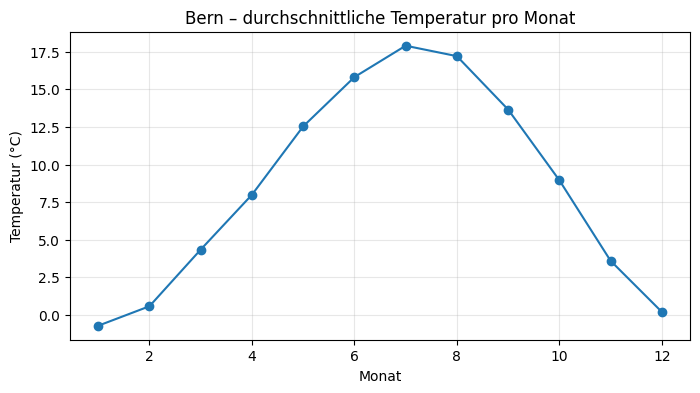

In [25]:
plt.figure(figsize=(8,4))
bern_monthly.plot(marker="o")
plt.title("Bern – durchschnittliche Temperatur pro Monat")
plt.xlabel("Monat")
plt.ylabel("Temperatur (°C)")
plt.grid(alpha=0.3)
plt.show()

In [26]:
for pid in ["zurich", "einsiedeln", "zermatt"]:
    row = places_eobs_checked.loc[places_eobs_checked["place_id"] == pid].iloc[0]
    ts = extract_eobs_value_nearest(tg_ch, row)
    print(pid, float(ts.mean().values))

zurich 9.452178001403809
einsiedeln 7.208832263946533
zermatt 0.41105911135673523


### 4.2 Datenexploration Zukunftsmodelle

In [27]:
def extract_ch2025_value_window_mean(data_array, place_row):
    subset = data_array.isel(
        y=slice(place_row["y_start"], place_row["y_end"]),
        x=slice(place_row["x_start"], place_row["x_end"])
    )
    return subset.mean(dim=("y", "x"))

Datenexploration am Beispiel von Bern

In [28]:
bern_row_ch2025 = places_ch2025_checked.loc[
    places_ch2025_checked["place_id"] == "bern"
].iloc[0]


In [29]:
bern_tas_ch2025 = extract_ch2025_value_window_mean(ds_tas_all["tas"], bern_row_ch2025)

bern_tas_ch2025

<xarray.DataArray 'tas' (scenario: 5, time: 10950)> Size: 219kB
dask.array<mean_agg-aggregate, shape=(5, 10950), dtype=float32, chunksize=(5, 365), chunktype=numpy.ndarray>
Coordinates:
  * scenario  (scenario) <U6 120B 'gwl1_5' 'gwl2_0' 'gwl2_5' 'gwl3_0' 'ref'
  * time      (time) object 88kB 0001-01-01 00:00:00 ... 0030-12-31 00:00:00
Attributes:
    units:           degrees_C
    grid_mapping:    swiss_lv95_coordinates
    esri_pe_string:  PROJCS["CH1903+_LV95",GEOGCS["GCS_CH1903+",DATUM["D_CH19...
    grid_name:       ch01r.swiss.lv95
    long_name:       Daily mean 2m temperature
    standard_name:   air_temperature
    method:          Bias-corrected and downscaled by QM

## 5. Lookup-Tabelle speichern

In [30]:
if DO_EXPORT:
    places_eobs_checked.to_parquet(EXPORT_DIR / "places_eobs_grid.parquet", index=False)

In [31]:
if DO_EXPORT:
    places_ch2025_checked.to_csv(
        EXPORT_DIR / "places_ch2025_grid.csv",
        index=False,
        sep=";"
    )

## 6. Berechnung und Export aller Orte

### 6.1 Berechnung historische Daten

#### 6.1.1 Durchschnittstemperatur historische Daten

In [32]:
def build_historical_place_profiles_temperature_mean(
    places_grid_df,
    tg_ch
):
    rows = []

    for _, place_row in places_grid_df.iterrows():
        ts = extract_eobs_value_nearest(tg_ch, place_row)
        monthly = ts.groupby("time.month").mean()

        for month in monthly["month"].values:
            value = monthly.sel(month=month).item()

            rows.append({
                "place_id": place_row["place_id"],
                "place_name": place_row["place_name"],
                "zone_expected": place_row["zone_expected"],
                "zone_actual": place_row.get("zone_actual", np.nan),
                "zone_match": place_row.get("zone_match", False),
                "dataset_type": "historical",
                "metric": "temperature_mean",
                "month": int(month),
                "value": float(value),
            })

    return pd.DataFrame(rows)

In [33]:
place_profiles_historical_temp = build_historical_place_profiles_temperature_mean(
    places_eobs_checked,
    tg_ch
)

place_profiles_historical_temp.head(15)

,place_id,place_name,zone_expected,zone_actual,zone_match,dataset_type,metric,month,value
0,aarau,Aarau,1,1,True,historical,temperature_mean,1,0.230206
1,aarau,Aarau,1,1,True,historical,temperature_mean,2,1.310210
2,aarau,Aarau,1,1,True,historical,temperature_mean,3,5.039131
3,aarau,Aarau,1,1,True,historical,temperature_mean,4,8.754486
4,aarau,Aarau,1,1,True,historical,temperature_mean,5,13.176672
5,aarau,Aarau,1,1,True,historical,temperature_mean,6,16.498503
6,aarau,Aarau,1,1,True,historical,temperature_mean,7,18.453445
7,aarau,Aarau,1,1,True,historical,temperature_mean,8,17.716904
8,aarau,Aarau,1,1,True,historical,temperature_mean,9,14.226799
9,aarau,Aarau,1,1,True,historical,temperature_mean,10,9.584623


In [34]:
place_profiles_historical_temp.query("place_id == 'bern'")

,place_id,place_name,zone_expected,zone_actual,zone_match,dataset_type,metric,month,value
252,bern,Bern,1,1,True,historical,temperature_mean,1,-0.726359
253,bern,Bern,1,1,True,historical,temperature_mean,2,0.569456
254,bern,Bern,1,1,True,historical,temperature_mean,3,4.337618
255,bern,Bern,1,1,True,historical,temperature_mean,4,7.988232
256,bern,Bern,1,1,True,historical,temperature_mean,5,12.535960
257,bern,Bern,1,1,True,historical,temperature_mean,6,15.816588
258,bern,Bern,1,1,True,historical,temperature_mean,7,17.904621
259,bern,Bern,1,1,True,historical,temperature_mean,8,17.210560
260,bern,Bern,1,1,True,historical,temperature_mean,9,13.657566
261,bern,Bern,1,1,True,historical,temperature_mean,10,8.952641


#### 6.1.2 Hot Days Monatsmittel historische Daten

In [35]:
def build_historical_place_profiles_hot_days_mean(
    places_grid_df,
    tx_ch
):
    rows = []

    hot_days = xr.where(tx_ch >= 30, 1, 0)

    for _, place_row in places_grid_df.iterrows():
        ts = extract_eobs_value_nearest(hot_days, place_row)

        monthly_mean = (
            ts.groupby("time.month")
              .mean()
        )

        for month in monthly_mean["month"].values:
            value = monthly_mean.sel(month=month).item()

            rows.append({
                "place_id": place_row["place_id"],
                "place_name": place_row["place_name"],
                "zone_expected": place_row["zone_expected"],
                "zone_actual": place_row.get("zone_actual", np.nan),
                "zone_match": place_row.get("zone_match", False),
                "dataset_type": "historical",
                "metric": "hot_days_mean",
                "month": int(month),
                "value": float(value),
            })

    return pd.DataFrame(rows)

Die Ausgabe der Hitzetage als Anteile pro Monat ist etwas missverständlich, sie wird später im Dashboard beim Erzeugen des Plots korrigiert.

In [36]:
place_profiles_historical_hot = build_historical_place_profiles_hot_days_mean(
    places_eobs_checked,
    tx_ch
)

place_profiles_historical_hot.head(15)

,place_id,place_name,zone_expected,zone_actual,zone_match,dataset_type,metric,month,value
0,aarau,Aarau,1,1,True,historical,hot_days_mean,1,0.000000
1,aarau,Aarau,1,1,True,historical,hot_days_mean,2,0.000000
2,aarau,Aarau,1,1,True,historical,hot_days_mean,3,0.000000
3,aarau,Aarau,1,1,True,historical,hot_days_mean,4,0.000000
4,aarau,Aarau,1,1,True,historical,hot_days_mean,5,0.004208
5,aarau,Aarau,1,1,True,historical,hot_days_mean,6,0.050725
6,aarau,Aarau,1,1,True,historical,hot_days_mean,7,0.112202
7,aarau,Aarau,1,1,True,historical,hot_days_mean,8,0.076204
8,aarau,Aarau,1,1,True,historical,hot_days_mean,9,0.000966
9,aarau,Aarau,1,1,True,historical,hot_days_mean,10,0.000000


#### 6.1.3 GDD monatliche Summe historische Daten

In [37]:
def build_historical_place_profiles_gdd(
    places_grid_df,
    tg_ch,
    base_temp=5
):
    rows = []

    gdd_daily = xr.where(tg_ch > base_temp, tg_ch - base_temp, 0)

    for _, place_row in places_grid_df.iterrows():
        ts = extract_eobs_value_nearest(gdd_daily, place_row)

        monthly_sum_per_year = ts.resample(time="MS").sum()
        monthly_mean = monthly_sum_per_year.groupby("time.month").mean("time")

        for month in monthly_mean["month"].values:
            value = monthly_mean.sel(month=month).item()

            rows.append({
                "place_id": place_row["place_id"],
                "place_name": place_row["place_name"],
                "zone_expected": place_row["zone_expected"],
                "zone_actual": place_row.get("zone_actual", np.nan),
                "zone_match": place_row.get("zone_match", False),
                "dataset_type": "historical",
                "scenario": None,
                "metric": "gdd",
                "month": int(month),
                "value": float(value),
            })

    return pd.DataFrame(rows)

In [38]:
place_profiles_historical_gdd = build_historical_place_profiles_gdd(
    places_eobs_checked,
    tg_ch
)

place_profiles_historical_gdd.head(15)

,place_id,place_name,zone_expected,zone_actual,zone_match,dataset_type,scenario,metric,month,value
0,aarau,Aarau,1,1,True,historical,None,gdd,1,6.069565
1,aarau,Aarau,1,1,True,historical,None,gdd,2,8.965217
2,aarau,Aarau,1,1,True,historical,None,gdd,3,49.542606
3,aarau,Aarau,1,1,True,historical,None,gdd,4,122.758392
4,aarau,Aarau,1,1,True,historical,None,gdd,5,253.782715
5,aarau,Aarau,1,1,True,historical,None,gdd,6,344.985107
6,aarau,Aarau,1,1,True,historical,None,gdd,7,417.056091
7,aarau,Aarau,1,1,True,historical,None,gdd,8,394.224030
8,aarau,Aarau,1,1,True,historical,None,gdd,9,276.803741
9,aarau,Aarau,1,1,True,historical,None,gdd,10,146.653778


### 6.2 Berechnung Zukunftsmodelle

#### 6.2.1 Durchschnittstemperatur Zukunftsmodelle

In [39]:
def build_future_place_profiles_temperature_mean(
    places_grid_df,
    tas_ch2025
):
    rows = []

    for _, place_row in places_grid_df.iterrows():
        ts = extract_ch2025_value_window_mean(tas_ch2025, place_row)

        monthly = ts.groupby("time.month").mean().compute()

        for scenario in monthly["scenario"].values:
            monthly_scenario = monthly.sel(scenario=scenario)

            for month in monthly_scenario["month"].values:
                value = monthly_scenario.sel(month=month).item()

                rows.append({
                    "place_id": place_row["place_id"],
                    "place_name": place_row["place_name"],
                    "zone_expected": place_row["zone_expected"],
                    "zone_actual": place_row.get("zone_actual", np.nan),
                    "zone_match": place_row.get("zone_match", False),
                    "dataset_type": "future",
                    "scenario": str(scenario),
                    "metric": "temperature_mean",
                    "month": int(month),
                    "value": float(value),
                })

    return pd.DataFrame(rows)

In [40]:
place_profiles_future_temp = build_future_place_profiles_temperature_mean(
    places_ch2025_checked,
    tas_ch2025
)

place_profiles_future_temp.head(20)

,place_id,place_name,zone_expected,zone_actual,zone_match,dataset_type,scenario,metric,month,value
0,aarau,Aarau,1,1,True,future,gwl1_5,temperature_mean,1,1.687742
1,aarau,Aarau,1,1,True,future,gwl1_5,temperature_mean,2,3.286717
2,aarau,Aarau,1,1,True,future,gwl1_5,temperature_mean,3,6.345717
3,aarau,Aarau,1,1,True,future,gwl1_5,temperature_mean,4,10.632783
4,aarau,Aarau,1,1,True,future,gwl1_5,temperature_mean,5,14.127833
5,aarau,Aarau,1,1,True,future,gwl1_5,temperature_mean,6,17.372692
6,aarau,Aarau,1,1,True,future,gwl1_5,temperature_mean,7,20.318758
7,aarau,Aarau,1,1,True,future,gwl1_5,temperature_mean,8,19.262861
8,aarau,Aarau,1,1,True,future,gwl1_5,temperature_mean,9,15.817546
9,aarau,Aarau,1,1,True,future,gwl1_5,temperature_mean,10,10.898895


In [41]:
place_profiles_future_temp.query("place_id == 'bern'")

,place_id,place_name,zone_expected,zone_actual,zone_match,dataset_type,scenario,metric,month,value
1260,bern,Bern,1,1,True,future,gwl1_5,temperature_mean,1,0.959980
1261,bern,Bern,1,1,True,future,gwl1_5,temperature_mean,2,2.706859
1262,bern,Bern,1,1,True,future,gwl1_5,temperature_mean,3,5.829960
1263,bern,Bern,1,1,True,future,gwl1_5,temperature_mean,4,9.954162
1264,bern,Bern,1,1,True,future,gwl1_5,temperature_mean,5,13.405541
1265,bern,Bern,1,1,True,future,gwl1_5,temperature_mean,6,16.721607
1266,bern,Bern,1,1,True,future,gwl1_5,temperature_mean,7,19.796057
1267,bern,Bern,1,1,True,future,gwl1_5,temperature_mean,8,18.736197
1268,bern,Bern,1,1,True,future,gwl1_5,temperature_mean,9,15.310285
1269,bern,Bern,1,1,True,future,gwl1_5,temperature_mean,10,10.353034


In [42]:
place_profiles_future_temp.query("place_id == 'bern' and scenario == 'gwl2_5'")

,place_id,place_name,zone_expected,zone_actual,zone_match,dataset_type,scenario,metric,month,value
1284,bern,Bern,1,1,True,future,gwl2_5,temperature_mean,1,2.049397
1285,bern,Bern,1,1,True,future,gwl2_5,temperature_mean,2,2.796828
1286,bern,Bern,1,1,True,future,gwl2_5,temperature_mean,3,6.603605
1287,bern,Bern,1,1,True,future,gwl2_5,temperature_mean,4,10.984823
1288,bern,Bern,1,1,True,future,gwl2_5,temperature_mean,5,14.394602
1289,bern,Bern,1,1,True,future,gwl2_5,temperature_mean,6,19.243805
1290,bern,Bern,1,1,True,future,gwl2_5,temperature_mean,7,21.301319
1291,bern,Bern,1,1,True,future,gwl2_5,temperature_mean,8,21.129120
1292,bern,Bern,1,1,True,future,gwl2_5,temperature_mean,9,17.240517
1293,bern,Bern,1,1,True,future,gwl2_5,temperature_mean,10,11.336757


In [43]:
place_profiles_future_temp.pivot_table(
    index="month",
    columns=["scenario", "place_name"],
    values="value"
)

scenario       gwl1_5                                                      \
place_name      Aarau  Adelboden   Adliswil   Aesch BL Affoltern am Albis   
month                                                                       
1            1.687742  -1.201483   1.514150   2.604346           1.521175   
2            3.286717  -0.496012   3.123136   4.039637           3.115949   
3            6.345717   1.643206   6.121488   6.965538           6.142535   
4           10.632783   4.954421  10.369101  11.018651          10.384969   
5           14.127833   8.450783  13.826740  14.370665          13.846515   
6           17.372692  11.631757  16.999151  17.607311          17.030878   
7           20.318758  14.623559  20.082380  20.689255          20.101063   
8           19.262861  13.794004  18.974094  19.773289          18.982613   
9           15.817546  11.035654  15.620488  16.300251          15.624231   
10          10.898895   7.202402  10.741849  11.553180          10.745584   
11           5.919971   3.386585   5.788335   6.555755           5.788272   
12           2.113716  -0.799940   1.904267   2.839226           1.923882   

scenario                                                           ...  \
place_name      Aigle  Allschwil Altdorf UR   Amriswil  Andermatt  ...   
month                                                              ...   
1            1.823423   3.117486   0.840495   1.642222  -4.049192  ...   
2            3.171946   4.525202   2.016724   2.978334  -3.695916  ...   
3            6.290654   7.460570   4.737453   5.934007  -1.556980  ...   
4           10.315882  11.527172   8.568065  10.244510   1.746897  ...   
5           13.688861  14.932350  12.252429  13.872630   4.875011  ...   
6           16.860134  18.184072  15.264442  17.065250   9.059359  ...   
7           19.665043  21.208450  17.978697  19.938368  12.238600  ...   
8           18.700651  20.230682  17.101841  18.934099  11.385458  ...   
9           15.408125  16.740835  14.197855  15.587166   8.635477  ...   
10          10.912103  11.967979   9.961516  10.711000   4.575372  ...   
11           6.380377   6.928180   5.572631   5.894582   0.567977  ...   
12           2.215266   3.285900   1.423343   2.074448  -3.685873  ...   

scenario          ref                                                         \
place_name     Luzern Pontresina   Saas-Fee    Samedan St. Gallen St. Moritz   
month                                                                          
1            1.163601  -8.102511  -5.388534  -8.060132   0.362288  -7.769760   
2            2.106490  -7.585296  -5.017798  -7.216746   1.032439  -7.103657   
3            4.921728  -5.248759  -2.969959  -4.412319   3.722290  -4.525713   
4           10.240054  -0.329524   1.403514   0.973494   8.908624   0.634323   
5           13.842896   3.095177   4.471734   4.545298  12.531248   4.153470   
6           16.959343   6.713602   8.304415   8.213805  15.465150   7.870512   
7           19.835485  10.326357  12.107121  11.506792  18.514748  11.277884   
8           18.430807   9.026252  10.850212  10.176365  17.121861   9.968309   
9           14.941476   5.926641   7.528625   6.942762  13.797046   6.781148   
10           9.762839   1.259375   2.864819   2.040821   8.862846   1.994079   
11           5.474122  -2.838132  -0.905100  -2.375891   4.822948  -2.262408   
12           1.887620  -6.940832  -4.498910  -6.883660   1.138136  -6.569533   

scenario                                                
place_name Winterthur    Zermatt       Zuoz     Zürich  
month                                                   
1            0.724129  -5.823421  -7.937932   1.113406  
2            1.701293  -5.536175  -7.180890   2.142425  
3            4.745772  -3.536913  -4.496048   5.154065  
4            9.920826   1.002284   0.812975  10.345095  
5           13.653150   4.298174   4.377206  14.009507  
6           16.644829   7.451849   7.912543  17.008547  
7           19.6153

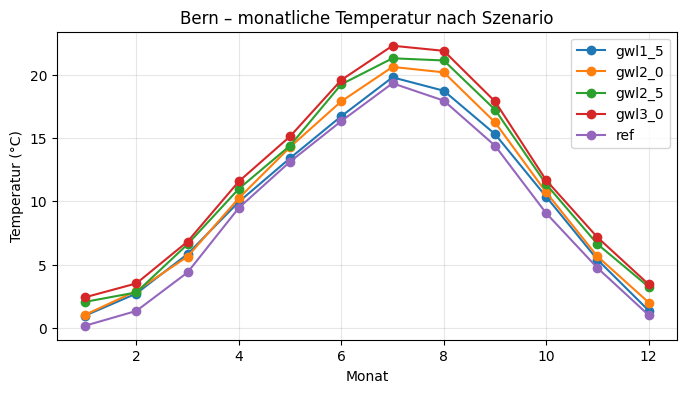

In [44]:
bern_future = place_profiles_future_temp.query("place_id == 'bern'")

plt.figure(figsize=(8, 4))

for scenario in bern_future["scenario"].unique():
    sub = bern_future[bern_future["scenario"] == scenario]
    plt.plot(sub["month"], sub["value"], marker="o", label=scenario)

plt.title("Bern – monatliche Temperatur nach Szenario")
plt.xlabel("Monat")
plt.ylabel("Temperatur (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#### 6.2.2 Hot Days Monatsmittel Zukunftsmodelle

In [45]:
def build_future_place_profiles_hot_days_mean(
    places_grid_df,
    tasmax_ch2025
):
    rows = []

    for _, place_row in places_grid_df.iterrows():
        # Erst kleines Ortsfenster extrahieren
        ts = extract_ch2025_value_window_mean(tasmax_ch2025, place_row)

        # Dann erst Hitzetage daraus ableiten
        hot_days_ts = xr.where(ts >= 30, 1, 0)

        # Monatsmittel pro Szenario
        monthly_mean = hot_days_ts.groupby("time.month").mean().compute()

        for scenario in monthly_mean["scenario"].values:
            monthly_scenario = monthly_mean.sel(scenario=scenario)

            for month in monthly_scenario["month"].values:
                value = monthly_scenario.sel(month=month).item()

                rows.append({
                    "place_id": place_row["place_id"],
                    "place_name": place_row["place_name"],
                    "zone_expected": place_row["zone_expected"],
                    "zone_actual": place_row.get("zone_actual", np.nan),
                    "zone_match": place_row.get("zone_match", False),
                    "dataset_type": "future",
                    "scenario": str(scenario),
                    "metric": "hot_days_mean",
                    "month": int(month),
                    "value": float(value),
                })

    return pd.DataFrame(rows)

Die Ausgabe der Hitzetage als Anteile pro Monat ist etwas missverständlich, sie wird später im Dashboard beim Erzeugen des Plots korrigiert.

In [46]:
place_profiles_future_hot = build_future_place_profiles_hot_days_mean(
    places_ch2025_checked,
    tasmax_ch2025
)

#### 6.2.3 GDD monatliche Summe Zukunftsmodelle

In [47]:
def build_future_place_profiles_gdd(
    places_grid_df,
    tas_ch2025,
    base_temp=5
):
    rows = []

    for _, place_row in places_grid_df.iterrows():
        ts = extract_ch2025_value_window_mean(tas_ch2025, place_row)

        gdd_daily = xr.where(ts > base_temp, ts - base_temp, 0)

        monthly_sum_per_year = gdd_daily.resample(time="MS").sum()
        monthly_mean = monthly_sum_per_year.groupby("time.month").mean("time").compute()

        for scenario in monthly_mean["scenario"].values:
            monthly_scenario = monthly_mean.sel(scenario=scenario)

            for month in monthly_scenario["month"].values:
                value = monthly_scenario.sel(month=month).compute().item()

                rows.append({
                    "place_id": place_row["place_id"],
                    "place_name": place_row["place_name"],
                    "zone_expected": place_row["zone_expected"],
                    "zone_actual": place_row.get("zone_actual", np.nan),
                    "zone_match": place_row.get("zone_match", False),
                    "dataset_type": "future",
                    "scenario": str(scenario),
                    "metric": "gdd",
                    "month": int(month),
                    "value": float(value),
                })

    return pd.DataFrame(rows)

In [48]:
place_profiles_future_gdd = build_future_place_profiles_gdd(
    places_ch2025_checked,
    tas_ch2025
)

## 7. Verknüpfung und Export Parameter-Tabellen

### 7.1. Verknüpfung und Export historische Daten

In [49]:
place_profiles_historical_all = pd.concat(
    [place_profiles_historical_temp, place_profiles_historical_hot, place_profiles_historical_gdd],
    ignore_index=True
)

In [50]:
place_profiles_historical_all["metric"].value_counts()

metric
temperature_mean    780
hot_days_mean       780
gdd                 780
Name: count, dtype: int64

In [51]:
if DO_EXPORT:
    place_profiles_historical_all.to_parquet(
        EXPORT_DIR / "place_profiles_historical.parquet",
        index=False
    )

### 7.2. Verknüpfung und Export Zukunftsmodelle

In [52]:
place_profiles_future_all = pd.concat(
    [place_profiles_future_temp, place_profiles_future_hot, place_profiles_future_gdd],
    ignore_index=True
)

place_profiles_future_all["metric"].value_counts()

metric
temperature_mean    3900
hot_days_mean       3900
gdd                 3900
Name: count, dtype: int64

In [53]:
if DO_EXPORT:
    place_profiles_future_all.to_parquet(
        EXPORT_DIR / "place_profiles_future.parquet",
        index=False
    )

### 7.3 Check Formate und Angleichen

In [54]:
print("HISTORICAL")
print(place_profiles_historical_all.columns.tolist())
print(place_profiles_historical_all.dtypes)
print()

print("FUTURE")
print(place_profiles_future_all.columns.tolist())
print(place_profiles_future_all.dtypes)

HISTORICAL
['place_id', 'place_name', 'zone_expected', 'zone_actual', 'zone_match', 'dataset_type', 'metric', 'month', 'value', 'scenario']
place_id             str
place_name           str
zone_expected      int64
zone_actual        int64
zone_match          bool
dataset_type         str
metric               str
month              int64
value            float64
scenario          object
dtype: object

FUTURE
['place_id', 'place_name', 'zone_expected', 'zone_actual', 'zone_match', 'dataset_type', 'scenario', 'metric', 'month', 'value']
place_id             str
place_name           str
zone_expected      int64
zone_actual        int64
zone_match          bool
dataset_type         str
scenario             str
metric               str
month              int64
value            float64
dtype: object


In [55]:
#Reihenfolge der Spalten definieren
column_order = [
    "place_id",
    "place_name",
    "zone_expected",
    "zone_actual",
    "zone_match",
    "dataset_type",
    "scenario",
    "metric",
    "month",
    "value",
]

In [56]:
#Zusätzliche Spalte setzen, damit gleiche Dimension
place_profiles_historical_all["scenario"] = "observed"

#Reihenfolge umsetzen
place_profiles_historical_all = place_profiles_historical_all[column_order]
place_profiles_future_all = place_profiles_future_all[column_order]

In [57]:
#Korrekte Reihenfolge prüfen
print("Historical metrics:", sorted(place_profiles_historical_all["metric"].unique()))
print("Future metrics:", sorted(place_profiles_future_all["metric"].unique()))

Historical metrics: ['gdd', 'hot_days_mean', 'temperature_mean']
Future metrics: ['gdd', 'hot_days_mean', 'temperature_mean']


In [58]:
#Datentyp setzen
place_profiles_historical_all["month"] = place_profiles_historical_all["month"].astype(int)
place_profiles_future_all["month"] = place_profiles_future_all["month"].astype(int)

place_profiles_historical_all["value"] = place_profiles_historical_all["value"].astype(float)
place_profiles_future_all["value"] = place_profiles_future_all["value"].astype(float)

place_profiles_historical_all["zone_match"] = place_profiles_historical_all["zone_match"].astype(bool)
place_profiles_future_all["zone_match"] = place_profiles_future_all["zone_match"].astype(bool)

In [59]:
#Für den Fall, dass zone_actual NaN enthält
place_profiles_historical_all["zone_actual"] = place_profiles_historical_all["zone_actual"].astype("Int64")
place_profiles_future_all["zone_actual"] = place_profiles_future_all["zone_actual"].astype("Int64")

### 7.4 Kombinierbarkeit historical und future testen

In [60]:
place_profiles_all = pd.concat(
    [place_profiles_historical_all, place_profiles_future_all],
    ignore_index=True
)

place_profiles_all.head()

,place_id,place_name,zone_expected,zone_actual,zone_match,dataset_type,scenario,metric,month,value
0,aarau,Aarau,1,1,True,historical,observed,temperature_mean,1,0.230206
1,aarau,Aarau,1,1,True,historical,observed,temperature_mean,2,1.310210
2,aarau,Aarau,1,1,True,historical,observed,temperature_mean,3,5.039131
3,aarau,Aarau,1,1,True,historical,observed,temperature_mean,4,8.754486
4,aarau,Aarau,1,1,True,historical,observed,temperature_mean,5,13.176672


In [61]:
place_profiles_all.groupby(["dataset_type", "scenario", "metric"]).size()

dataset_type  scenario  metric          
future        gwl1_5    gdd                 780
                        hot_days_mean       780
                        temperature_mean    780
              gwl2_0    gdd                 780
                        hot_days_mean       780
                        temperature_mean    780
              gwl2_5    gdd                 780
                        hot_days_mean       780
                        temperature_mean    780
              gwl3_0    gdd                 780
                        hot_days_mean       780
                        temperature_mean    780
              ref       gdd                 780
                        hot_days_mean       780
                        temperature_mean    780
historical    observed  gdd                 780
                        hot_days_mean       780
                        temperature_mean    780
dtype: int64

In [62]:
place_profiles_all.query("place_id == 'bern' and metric == 'temperature_mean'")

,place_id,place_name,zone_expected,zone_actual,zone_match,dataset_type,scenario,metric,month,value
252,bern,Bern,1,1,True,historical,observed,temperature_mean,1,-0.726359
253,bern,Bern,1,1,True,historical,observed,temperature_mean,2,0.569456
254,bern,Bern,1,1,True,historical,observed,temperature_mean,3,4.337618
255,bern,Bern,1,1,True,historical,observed,temperature_mean,4,7.988232
256,bern,Bern,1,1,True,historical,observed,temperature_mean,5,12.535960
...,...,...,...,...,...,...,...,...,...,...
3655,bern,Bern,1,1,True,future,ref,temperature_mean,8,17.954292
3656,bern,Bern,1,1,True,future,ref,temperature_mean,9,14.395713
3657,bern,Bern,1,1,True,future,ref,temperature_mean,10,9.049117
3658,bern,Bern,1,1,True,future,ref,temperature_mean,11,4.728701


In [63]:
place_profiles_all.query("place_id == 'gstaad' and metric == 'hot_days_mean'")

,place_id,place_name,zone_expected,zone_actual,zone_match,dataset_type,scenario,metric,month,value
1368,gstaad,Gstaad,2,2,True,historical,observed,hot_days_mean,1,0.000000
1369,gstaad,Gstaad,2,2,True,historical,observed,hot_days_mean,2,0.000000
1370,gstaad,Gstaad,2,2,True,historical,observed,hot_days_mean,3,0.000000
1371,gstaad,Gstaad,2,2,True,historical,observed,hot_days_mean,4,0.000000
1372,gstaad,Gstaad,2,2,True,historical,observed,hot_days_mean,5,0.000000
...,...,...,...,...,...,...,...,...,...,...
9235,gstaad,Gstaad,2,2,True,future,ref,hot_days_mean,8,0.008602
9236,gstaad,Gstaad,2,2,True,future,ref,hot_days_mean,9,0.000000
9237,gstaad,Gstaad,2,2,True,future,ref,hot_days_mean,10,0.000000
9238,gstaad,Gstaad,2,2,True,future,ref,hot_days_mean,11,0.000000


In [64]:
place_profiles_all.query("place_id == 'einsiedeln' and metric == 'gdd'")

,place_id,place_name,zone_expected,zone_actual,zone_match,dataset_type,scenario,metric,month,value
2076,einsiedeln,Einsiedeln,2,2,True,historical,observed,gdd,1,1.615217
2077,einsiedeln,Einsiedeln,2,2,True,historical,observed,gdd,2,3.292753
2078,einsiedeln,Einsiedeln,2,2,True,historical,observed,gdd,3,23.964781
2079,einsiedeln,Einsiedeln,2,2,True,historical,observed,gdd,4,74.191307
2080,einsiedeln,Einsiedeln,2,2,True,historical,observed,gdd,5,183.350998
...,...,...,...,...,...,...,...,...,...,...
12775,einsiedeln,Einsiedeln,2,2,True,future,ref,gdd,8,323.587524
12776,einsiedeln,Einsiedeln,2,2,True,future,ref,gdd,9,217.427048
12777,einsiedeln,Einsiedeln,2,2,True,future,ref,gdd,10,101.764397
12778,einsiedeln,Einsiedeln,2,2,True,future,ref,gdd,11,30.880646


In [65]:
place_profiles_all.query(
    "place_id == 'bern' and metric == 'temperature_mean'"
).pivot_table(
    index="month",
    columns="scenario",
    values="value"
)

scenario,gwl1_5,gwl2_0,gwl2_5,gwl3_0,observed,ref
month,,,,,,
1,0.959980,1.026383,2.049397,2.412849,-0.726359,0.163494
2,2.706859,2.911396,2.796828,3.506143,0.569456,1.331384
3,5.829960,5.630391,6.603605,6.813508,4.337618,4.376493
4,9.954162,10.241878,10.984823,11.568588,7.988232,9.478035
5,13.405541,14.281787,14.394602,15.125775,12.535960,13.126474
6,16.721607,17.896523,19.243805,19.582911,15.816588,16.334183
7,19.796057,20.619963,21.301319,22.294430,17.904621,19.326218
8,18.736197,20.190437,21.129120,21.891823,17.210560,17.954292
9,15.310285,16.244383,17.240517,17.890766,13.657566,14.395713


## 8. Finaler Export

In [66]:
if DO_EXPORT:
    place_profiles_all.to_parquet(
        EXPORT_DIR / "place_profiles_all.parquet",
        index=False
    )

Scatterplot GDD und Hitzetage, Export für Dash, Section C: Wurde in der finalen Version des Dashboards nicht mehr verwendet.

In [67]:
# # -------------------------------------------------------------------
# # Zusatzexport für Section C:
# # GDD vs. Hitzetage, historische Referenzperiode 1991–2020
# # -------------------------------------------------------------------
#
# SCATTER_EXPORT_PATH = EXPORT_DIR / "gdd_hotdays_scatter_1991_2020.parquet"
#
# # 1) Historische Daten auf Referenzperiode filtern
# # Annahme: place_profiles_all enthält noch KEIN year.
# # Darum berechnen wir Section-C-Daten direkt aus den täglichen E-OBS-Daten neu.
#
# def build_gdd_hotdays_scatter_1991_2020(
#     places_grid_df,
#     tg_ch,
#     tx_ch,
#     places_df,
#     start_year=1991,
#     end_year=2020,
#     base_temp=5,
# ):
#     rows = []
#
#     # Zeitraum auf 1991–2020 beschränken
#     tg_period = tg_ch.sel(
#         time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
#     )
#     tx_period = tx_ch.sel(
#         time=slice(f"{start_year}-01-01", f"{end_year}-12-31")
#     )
#
#     # Tagesbasierte Metriken
#     gdd_daily = xr.where(tg_period > base_temp, tg_period - base_temp, 0)
#     hot_days_daily = xr.where(tx_period >= 30, 1, 0)
#
#     for _, place_row in places_grid_df.iterrows():
#         place_id = place_row["place_id"]
#
#         # GDD-Zeitreihe für Ort
#         gdd_ts = extract_eobs_value_nearest(gdd_daily, place_row)
#         hot_ts = extract_eobs_value_nearest(hot_days_daily, place_row)
#
#         # In DataFrames umwandeln
#         gdd_df = gdd_ts.to_dataframe(name="gdd").reset_index()
#         hot_df = hot_ts.to_dataframe(name="hot_day").reset_index()
#
#         gdd_df["year"] = pd.to_datetime(gdd_df["time"]).dt.year
#         hot_df["year"] = pd.to_datetime(hot_df["time"]).dt.year
#
#         # Jahreswerte berechnen
#         gdd_yearly = (
#             gdd_df.groupby("year", as_index=False)["gdd"]
#             .sum()
#         )
#
#         hot_yearly = (
#             hot_df.groupby("year", as_index=False)["hot_day"]
#             .sum()
#         )
#
#         # Durchschnitt über 1991–2020
#         gdd_mean = gdd_yearly["gdd"].mean()
#         hot_days_mean = hot_yearly["hot_day"].mean()
#
#         rows.append({
#             "place_id": place_id,
#             "place_name": place_row["place_name"],
#             "zone_expected": place_row["zone_expected"],
#             "gdd": float(gdd_mean),
#             "hot_days_mean": float(hot_days_mean),
#         })
#
#     scatter_df = pd.DataFrame(rows)
#
#     # Zusatzinformationen aus places.csv anhängen
#     cols_to_merge = [
#         col for col in ["place_id", "elevation_m", "zone_label"]
#         if col in places_df.columns
#     ]
#
#     if "place_id" in cols_to_merge:
#         scatter_df = scatter_df.merge(
#             places_df[cols_to_merge],
#             on="place_id",
#             how="left"
#         )
#
#     return scatter_df
#
#
# gdd_hotdays_scatter_1991_2020 = build_gdd_hotdays_scatter_1991_2020(
#     places_grid_df=places_eobs_checked,
#     tg_ch=tg_ch,
#     tx_ch=tx_ch,
#     places_df=places,
#     start_year=1991,
#     end_year=2020,
#     base_temp=5,
# )
#
# # Kurzer Check
# display(gdd_hotdays_scatter_1991_2020)
# print(gdd_hotdays_scatter_1991_2020.describe())
#
# # Export nur für Section C
# gdd_hotdays_scatter_1991_2020.to_parquet(
#     SCATTER_EXPORT_PATH,
#     index=False
# )
#
# print(f"Exportiert: {SCATTER_EXPORT_PATH}")